# Analyse & Exploitation des données SNCF


### Maintenance Prédictive & Expérience Voyageur

Nosaiba Elkrekshi

Mastère 1 Data & IA — Nexa Digital School

Ce notebook couvre l'exploitation des données open data SNCF : chargement, base SQLite,
nettoyage, contrôle qualité, modélisation (Random Forest + LSTM) et visualisation.

In [ ]:
# Téléchargement des données
import os
import pandas as pd

# ============================
# TÉLÉCHARGEMENT DIRECT SNCF
# ============================

# Dataset 1 - Régularité mensuelle TGV
url1 = "https://ressources.data.sncf.com/api/explore/v2.1/catalog/datasets/reglarite-mensuelle-tgv-nationale/exports/csv?delimiter=%3B&lang=fr&timezone=Europe%2FParis"

# Dataset 2 - Régularité TGV par liaisons
url2 = "https://ressources.data.sncf.com/api/explore/v2.1/catalog/datasets/regularite-mensuelle-tgv-aqst/exports/csv?delimiter=%3B&lang=fr&timezone=Europe%2FParis"

# Dataset 3 - Fréquentation gares
url3 = "https://ressources.data.sncf.com/api/explore/v2.1/catalog/datasets/frequentation-gares/exports/csv?delimiter=%3B&lang=fr&timezone=Europe%2FParis"

# Téléchargement UNE seule fois, puis on repart de l'instantané figé
if os.path.exists('snap_regularite.csv'):
    df_regularite    = pd.read_csv('snap_regularite.csv')
    df_liaisons      = pd.read_csv('snap_liaisons.csv')
    df_frequentation = pd.read_csv('snap_frequentation.csv')
    print("✅ Données chargées depuis l'instantané figé")
else:
    df_regularite    = pd.read_csv(url1, sep=';')
    df_liaisons      = pd.read_csv(url2, sep=';')
    df_frequentation = pd.read_csv(url3, sep=';')
    df_regularite.to_csv('snap_regularite.csv', index=False)
    df_liaisons.to_csv('snap_liaisons.csv', index=False)
    df_frequentation.to_csv('snap_frequentation.csv', index=False)
    print("✅ Données téléchargées et figées")


✅ Données chargées depuis l'instantané figé


In [ ]:
# ============================
# EXPLORATION DATASET 1
# ============================
print("\n" + "="*50)
print("DATASET 1 - Régularité mensuelle TGV")
print("="*50)
print(f"Nombre de lignes    : {df_regularite.shape[0]}")
print(f"Nombre de colonnes  : {df_regularite.shape[1]}")
print("\nNoms des colonnes :")
print(list(df_regularite.columns))
print("\nTypes des colonnes :")
print(df_regularite.dtypes)
print("\nAperçu :")
print(df_regularite.head(3))
print("\nValeurs manquantes :")
print(df_regularite.isnull().sum())


DATASET 1 - Régularité mensuelle TGV
Nombre de lignes    : 138
Nombre de colonnes  : 3

Noms des colonnes :
['date', 'regularite_composite', 'ponctualite_origine']

Types des colonnes :
date                     object
regularite_composite    float64
ponctualite_origine     float64
dtype: object

Aperçu :
      date  regularite_composite  ponctualite_origine
0  2015-01             91.627358            85.280538
1  2015-02             90.325652            84.248184
2  2015-03             93.421794            87.453249

Valeurs manquantes :
date                    0
regularite_composite    0
ponctualite_origine     0
dtype: int64


In [ ]:
# ============================
# EXPLORATION DATASET 2
# ============================
print("\n" + "="*50)
print("DATASET 2 - Régularité TGV par liaisons")
print("="*50)
print(f"Nombre de lignes    : {df_liaisons.shape[0]}")
print(f"Nombre de colonnes  : {df_liaisons.shape[1]}")
print("\nNoms des colonnes :")
print(list(df_liaisons.columns))
print("\nTypes des colonnes :")
print(df_liaisons.dtypes)
print("\nAperçu :")
print(df_liaisons.head(3))
print("\nValeurs manquantes :")
print(df_liaisons.isnull().sum())


DATASET 2 - Régularité TGV par liaisons
Nombre de lignes    : 12544
Nombre de colonnes  : 26

Noms des colonnes :
['date', 'service', 'gare_depart', 'gare_arrivee', 'duree_moyenne', 'nb_train_prevu', 'nb_annulation', 'commentaire_annulation', 'nb_train_depart_retard', 'retard_moyen_depart', 'retard_moyen_tous_trains_depart', 'commentaire_retards_depart', 'nb_train_retard_arrivee', 'retard_moyen_arrivee', 'retard_moyen_tous_trains_arrivee', 'commentaires_retard_arrivee', 'nb_train_retard_sup_15', 'retard_moyen_trains_retard_sup15', 'nb_train_retard_sup_30', 'nb_train_retard_sup_60', 'prct_cause_externe', 'prct_cause_infra', 'prct_cause_gestion_trafic', 'prct_cause_materiel_roulant', 'prct_cause_gestion_gare', 'prct_cause_prise_en_charge_voyageurs']

Types des colonnes :
date                                     object
service                                  object
gare_depart                              object
gare_arrivee                             object
duree_moyenne              

In [ ]:
# ============================
# EXPLORATION DATASET 3
# ============================
print("\n" + "="*50)
print("DATASET 3 - Fréquentation gares")
print("="*50)
print(f"Nombre de lignes    : {df_frequentation.shape[0]}")
print(f"Nombre de colonnes  : {df_frequentation.shape[1]}")
print("\nNoms des colonnes :")
print(list(df_frequentation.columns))
print("\nTypes des colonnes :")
print(df_frequentation.dtypes)
print("\nAperçu :")
print(df_frequentation.head(3))
print("\nValeurs manquantes :")
print(df_frequentation.isnull().sum())

print("\n Exploration terminée !")


DATASET 3 - Fréquentation gares
Nombre de lignes    : 3021
Nombre de colonnes  : 27

Noms des colonnes :
['nom_gare', 'code_uic_complet', 'code_postal', 'direction_regionale_gares', 'segmentation_drg', 'segmentation_marketing', 'non_voyageurs', 'total_voyageurs_2024', 'total_voyageurs_non_voyageurs_2024', 'total_voyageurs_2023', 'total_voyageurs_non_voyageurs_2023', 'total_voyageurs_2022', 'total_voyageurs_non_voyageurs_2022', 'total_voyageurs_2021', 'total_voyageurs_non_voyageurs_2021', 'total_voyageurs_2020', 'total_voyageurs_non_voyageurs_2020', 'total_voyageurs_2019', 'total_voyageurs_non_voyageurs_2019', 'total_voyageurs_2018', 'total_voyageurs_non_voyageurs_2018', 'totalvoyageurs2017', 'total_voyageurs_non_voyageurs_2017', 'total_voyageurs_2016', 'total_voyageurs_non_voyageurs_2016', 'total_voyageurs_2015', 'total_voyageurs_non_voyageurs_2015']

Types des colonnes :
nom_gare                               object
code_uic_complet                        int64
code_postal           

## Étape 1 — Installation de la base de données SQLite
Centralisation des trois sources dans une base relationnelle `sncf_maintenance.db`.

In [ ]:
# Base de données SQLite

import pandas as pd
import sqlite3
import os

# ============================
# RECHARGEMENT DES DONNÉES
# ============================
url1 = "https://ressources.data.sncf.com/api/explore/v2.1/catalog/datasets/reglarite-mensuelle-tgv-nationale/exports/csv?delimiter=%3B&lang=fr&timezone=Europe%2FParis"
url2 = "https://ressources.data.sncf.com/api/explore/v2.1/catalog/datasets/regularite-mensuelle-tgv-aqst/exports/csv?delimiter=%3B&lang=fr&timezone=Europe%2FParis"
url3 = "https://ressources.data.sncf.com/api/explore/v2.1/catalog/datasets/frequentation-gares/exports/csv?delimiter=%3B&lang=fr&timezone=Europe%2FParis"

df_regularite     = pd.read_csv(url1, sep=';')
df_liaisons       = pd.read_csv(url2, sep=';')
df_frequentation  = pd.read_csv(url3, sep=';')

print("✅ Données rechargées")

# ============================
# ÉTAPE 1 — BASE DE DONNÉES SQLITE
# ============================
print("\n" + "="*50)
print("ÉTAPE 1 — INSTALLATION BASE DE DONNÉES SQLITE")
print("="*50)

# Création de la base de données
conn = sqlite3.connect('sncf_maintenance.db')
cursor = conn.cursor()

# Chargement des tables dans SQLite
df_regularite.to_sql('regularite_tgv', conn, if_exists='replace', index=False)
df_liaisons.to_sql('liaisons_tgv', conn, if_exists='replace', index=False)
df_frequentation.to_sql('frequentation_gares', conn, if_exists='replace', index=False)

print(" Base de données 'sncf_maintenance.db' créée avec succès")

# Affichage des tables disponibles
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"\nTables disponibles dans la base :")
for t in tables:
    print(f"  → {t[0]}")

# Affichage du nombre de lignes par table
print("\nVérification du contenu :")
for t in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {t[0]}")
    count = cursor.fetchone()[0]
    print(f"  → {t[0]} : {count} enregistrements")

✅ Données rechargées

ÉTAPE 1 — INSTALLATION BASE DE DONNÉES SQLITE
 Base de données 'sncf_maintenance.db' créée avec succès

Tables disponibles dans la base :
  → regularite_tgv
  → liaisons_tgv
  → frequentation_gares

Vérification du contenu :
  → regularite_tgv : 138 enregistrements
  → liaisons_tgv : 12544 enregistrements
  → frequentation_gares : 3021 enregistrements


## Étape 2 — Nettoyage et contrôle qualité
Analyse des valeurs manquantes, puis contrôle des incohérences (doublons, valeurs hors intervalle).

In [ ]:
# Nettoyage Dataset 1

# ============================
# ÉTAPE 2 — NETTOYAGE DES DONNÉES
# ============================
print("\n" + "="*50)
print("ÉTAPE 2 — ANALYSE ET NETTOYAGE DES DONNÉES")
print("="*50)

# ---- DATASET 1 ----
print("\n--- Dataset 1 : Régularité TGV nationale ---")
print(f"Valeurs manquantes avant nettoyage :\n{df_regularite.isnull().sum()}")

# Conversion de la date en format datetime
df_regularite['date'] = pd.to_datetime(df_regularite['date'])
print(f"\n Colonne 'date' convertie en datetime")
print(f"Période couverte : {df_regularite['date'].min()} → {df_regularite['date'].max()}")
print(f"Valeurs manquantes après nettoyage : {df_regularite.isnull().sum().sum()}")


ÉTAPE 2 — ANALYSE ET NETTOYAGE DES DONNÉES

--- Dataset 1 : Régularité TGV nationale ---
Valeurs manquantes avant nettoyage :
date                    0
regularite_composite    0
ponctualite_origine     0
dtype: int64

 Colonne 'date' convertie en datetime
Période couverte : 2015-01-01 00:00:00 → 2026-06-01 00:00:00
Valeurs manquantes après nettoyage : 0


In [ ]:
# Nettoyage Dataset 2

# ---- DATASET 2 ----
print("\n--- Dataset 2 : Régularité TGV par liaisons ---")
print(f"Valeurs manquantes AVANT nettoyage :")
vides = df_liaisons.isnull().sum()
print(vides[vides > 0])

# Suppression des colonnes commentaires (100% vides, non exploitables)
cols_a_supprimer = ['commentaire_annulation',
                    'commentaire_retards_depart',
                    'commentaires_retard_arrivee']
df_liaisons = df_liaisons.drop(columns=cols_a_supprimer)
print(f"\n Colonnes commentaires supprimées (100% valeurs manquantes)")

# Conversion de la date
df_liaisons['date'] = pd.to_datetime(df_liaisons['date'])
print(f" Colonne 'date' convertie en datetime")

# Vérification finale
print(f"\nValeurs manquantes APRÈS nettoyage : {df_liaisons.isnull().sum().sum()}")
print(f"Dimensions finales : {df_liaisons.shape[0]} lignes x {df_liaisons.shape[1]} colonnes")


--- Dataset 2 : Régularité TGV par liaisons ---
Valeurs manquantes AVANT nettoyage :
commentaire_annulation         12544
commentaire_retards_depart     12544
commentaires_retard_arrivee    11846
dtype: int64

 Colonnes commentaires supprimées (100% valeurs manquantes)
 Colonne 'date' convertie en datetime

Valeurs manquantes APRÈS nettoyage : 0
Dimensions finales : 12544 lignes x 23 colonnes


In [ ]:
# Nettoyage Dataset 3

# ---- DATASET 3 ----
print("\n--- Dataset 3 : Fréquentation gares ---")
print(f"Valeurs manquantes AVANT nettoyage :")
vides3 = df_frequentation.isnull().sum()
print(vides3[vides3 > 0])

# Remplacement des valeurs manquantes catégorielles par 'Non renseigné'
df_frequentation['direction_regionale_gares'] = df_frequentation['direction_regionale_gares'].fillna('Non renseigné')
df_frequentation['segmentation_drg'] = df_frequentation['segmentation_drg'].fillna('Non renseigné')
df_frequentation['segmentation_marketing'] = df_frequentation['segmentation_marketing'].fillna('Non renseigné')

print(f"\n Valeurs manquantes remplacées par 'Non renseigné'")
print(f"Valeurs manquantes APRÈS nettoyage : {df_frequentation.isnull().sum().sum()}")
print(f"Dimensions finales : {df_frequentation.shape[0]} lignes x {df_frequentation.shape[1]} colonnes")


--- Dataset 3 : Fréquentation gares ---
Valeurs manquantes AVANT nettoyage :
direction_regionale_gares     11
segmentation_drg              70
segmentation_marketing       125
dtype: int64

 Valeurs manquantes remplacées par 'Non renseigné'
Valeurs manquantes APRÈS nettoyage : 0
Dimensions finales : 3021 lignes x 27 colonnes


In [ ]:
# ============================
# ÉTAPE 2bis — CONTRÔLE DES INCOHÉRENCES
# ============================
# Au-delà des valeurs manquantes, on vérifie la cohérence "métier" des données :
# doublons, retards négatifs, pourcentages hors de l'intervalle [0, 100],
# et taux de régularité hors [0, 100].
print("\n" + "="*50)
print("ÉTAPE 2bis — ANALYSE DES INCOHÉRENCES")
print("="*50)

# --- 1) Doublons ---
print("\n--- Doublons ---")
print(f"Dataset 2 (liaisons)      : {df_liaisons.duplicated().sum()} lignes dupliquées")
print(f"Dataset 1 (régularité)    : {df_regularite.duplicated().sum()} lignes dupliquées")
print(f"Dataset 3 (fréquentation) : {df_frequentation.duplicated().sum()} lignes dupliquées")

# --- 2) Retards négatifs (train en avance en moyenne) ---
nb_retard_neg = (df_liaisons['retard_moyen_arrivee'] < 0).sum()
print("\n--- Retards négatifs (arrivée en avance) ---")
print(f"Nombre de couples liaison-mois concernés : {nb_retard_neg}")
if nb_retard_neg > 0:
    print(f"Valeur minimale observée : {df_liaisons['retard_moyen_arrivee'].min():.2f} min")
    print("=> Valeurs rares mais plausibles (avance moyenne) : conservées, pas d'erreur de saisie.")

# --- 3) Pourcentages de causes hors de [0, 100] ---
cols_prct = [c for c in df_liaisons.columns if c.startswith('prct_cause')]
print("\n--- Pourcentages de causes hors [0, 100] ---")
for c in cols_prct:
    hors = ((df_liaisons[c] < 0) | (df_liaisons[c] > 100)).sum()
    print(f"  {c} : {hors} valeur(s) hors intervalle")

# --- 4) Taux de régularité hors [0, 100] ---
hors_reg = ((df_regularite['regularite_composite'] < 0) |
            (df_regularite['regularite_composite'] > 100)).sum()
print("\n--- Taux de régularité hors [0, 100] ---")
print(f"  regularite_composite : {hors_reg} valeur(s) hors intervalle")

print("\nConclusion : aucune incohérence structurelle bloquante détectée.")
print("Les seules valeurs 'atypiques' (retards négatifs) sont des cas réels rares, conservés.")


ÉTAPE 2bis — ANALYSE DES INCOHÉRENCES

--- Doublons ---
Dataset 2 (liaisons)      : 0 lignes dupliquées
Dataset 1 (régularité)    : 0 lignes dupliquées
Dataset 3 (fréquentation) : 0 lignes dupliquées

--- Retards négatifs (arrivée en avance) ---
Nombre de couples liaison-mois concernés : 2
Valeur minimale observée : -40.11 min
=> Valeurs rares mais plausibles (avance moyenne) : conservées, pas d'erreur de saisie.

--- Pourcentages de causes hors [0, 100] ---
  prct_cause_externe : 0 valeur(s) hors intervalle
  prct_cause_infra : 0 valeur(s) hors intervalle
  prct_cause_gestion_trafic : 0 valeur(s) hors intervalle
  prct_cause_materiel_roulant : 0 valeur(s) hors intervalle
  prct_cause_gestion_gare : 0 valeur(s) hors intervalle
  prct_cause_prise_en_charge_voyageurs : 0 valeur(s) hors intervalle

--- Taux de régularité hors [0, 100] ---
  regularite_composite : 0 valeur(s) hors intervalle

Conclusion : aucune incohérence structurelle bloquante détectée.
Les seules valeurs 'atypiques' (

In [ ]:
# ============================
# FIGER LA PÉRIODE D'ANALYSE À MARS 2026
# janvier 2015 -> mars 2026)
# Les données SNCF sont en direct et grandissent ; on fige la période
# pour que les résultats soient reproductibles et identiques au mémoire.
# ============================
df_liaisons   = df_liaisons[df_liaisons["date"] <= "2026-03-31"]
df_regularite = df_regularite[df_regularite["date"] <= "2026-03-31"]

print("Après filtrage de la période (<= mars 2026) :")
print("  liaisons_tgv :", df_liaisons.shape[0], "lignes")   # doit afficher ~12 181
print("  regularite   :", df_regularite.shape[0], "lignes")


Après filtrage de la période (<= mars 2026) :
  liaisons_tgv : 12181 lignes
  regularite   : 135 lignes


## Étape 3 — Sécurisation des données
Sauvegarde des données nettoyées, mise à jour de la base et statistiques descriptives.

In [ ]:
# Sécurisation + statistiques

# ============================
# ÉTAPE 3 — SÉCURISATION
# ============================
print("\n" + "="*50)
print("ÉTAPE 3 — SÉCURISATION DES DONNÉES")
print("="*50)

# Sauvegarde sécurisée des données nettoyées
df_regularite.to_csv('regularite_nettoye.csv', index=False)
df_liaisons.to_csv('liaisons_nettoye.csv', index=False)
df_frequentation.to_csv('frequentation_nettoye.csv', index=False)

print(" Fichiers nettoyés sauvegardés localement")

# Rechargement dans SQLite avec données nettoyées
df_regularite.to_sql('regularite_tgv', conn, if_exists='replace', index=False)
df_liaisons.to_sql('liaisons_tgv', conn, if_exists='replace', index=False)
df_frequentation.to_sql('frequentation_gares', conn, if_exists='replace', index=False)

print(" Base de données mise à jour avec les données nettoyées")

# Vérification taille base de données
taille = os.path.getsize('sncf_maintenance.db')
print(f" Taille de la base de données : {taille/1024:.1f} Ko")

# Statistiques descriptives Dataset 2 (le plus important)
print("\n--- Statistiques descriptives Dataset 2 ---")
print(df_liaisons[['retard_moyen_arrivee',
                    'nb_train_retard_sup_15',
                    'prct_cause_materiel_roulant',
                    'prct_cause_infra']].describe().round(2))

conn.close()
print("\n Connexion base de données fermée proprement")
print("\n ÉTAPES 1, 2 et 3 TERMINÉES")


ÉTAPE 3 — SÉCURISATION DES DONNÉES
 Fichiers nettoyés sauvegardés localement
 Base de données mise à jour avec les données nettoyées
 Taille de la base de données : 2820.0 Ko

--- Statistiques descriptives Dataset 2 ---
       retard_moyen_arrivee  nb_train_retard_sup_15  \
count              12181.00                12181.00   
mean                  35.21                   27.09   
std                   15.55                   22.86   
min                  -40.11                    0.00   
25%                   25.81                   11.00   
50%                   33.50                   22.00   
75%                   42.46                   37.00   
max                  299.60                  312.00   

       prct_cause_materiel_roulant  prct_cause_infra  
count                     12181.00          12181.00  
mean                         18.88             21.77  
std                          13.49             14.87  
min                           0.00              0.00  
25%     

## Étape 4 — Modélisation IA

**Random Forest** (classification) pour le risque matériel roulant, **LSTM** (deep learning) pour la régularité.

> **Pas de fuite d'information :** les six `prct_cause_*` somment à 100 % et sont donc liées à la cible.
> Le Random Forest n'utilise que des variables opérationnelles indépendantes. Le résultat honnête (AUC ≈ 0,70)
> reflète la vraie difficulté du problème sur des données agrégées.

Données rechargées : (12181, 23)
Seuil de risque (médiane) : 17.02%
Répartition des classes :
risque_materiel
1    6095
0    6086
Name: count, dtype: int64

Nombre de features : 13
Entraînement : 8526 obs. | Test : 3655 obs.
Modèle entraîné.

--- MÉTRIQUES D'ÉVALUATION (sans fuite) ---
Accuracy  : 0.6386 (63.86%)
F1-Score  : 0.6386
AUC-ROC   : 0.7009

Rapport de classification :
               precision    recall  f1-score   support

Risque Faible       0.64      0.64      0.64      1826
 Risque Élevé       0.64      0.64      0.64      1829

     accuracy                           0.64      3655
    macro avg       0.64      0.64      0.64      3655
 weighted avg       0.64      0.64      0.64      3655

Validation croisée 5-fold — F1 moyen : 0.6420 ± 0.0050

--- IMPORTANCE DES VARIABLES ---
                         feature  importance
             retard_moyen_depart    0.146123
retard_moyen_tous_trains_arrivee    0.100967
                  nb_train_prevu    0.095007
 retard_moyen_to

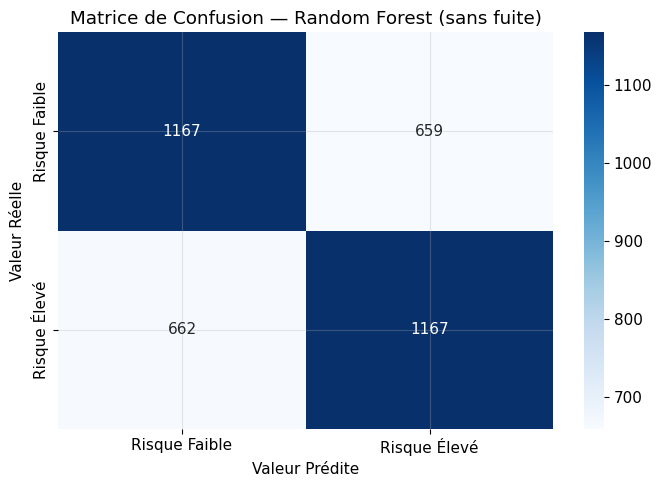

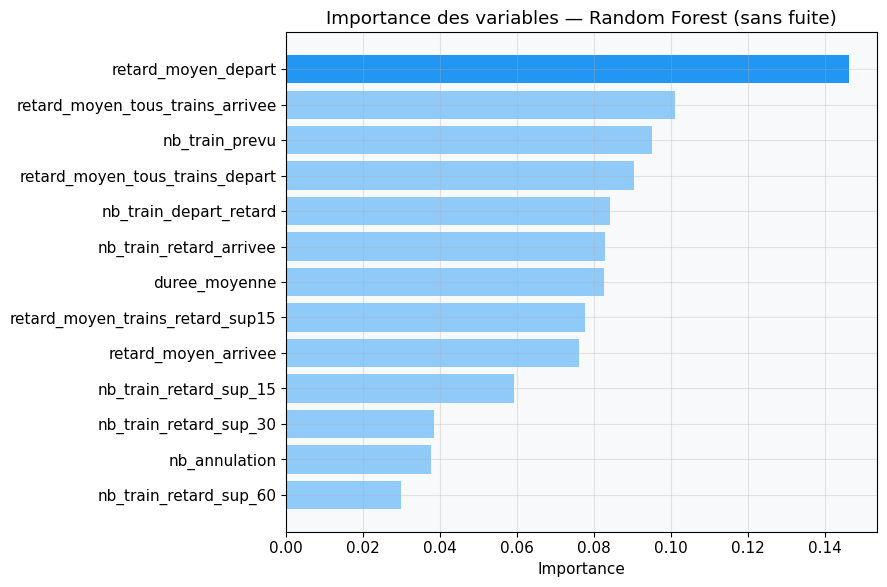


Figures sauvegardées : matrice_confusion.png, importance_variables.png


In [ ]:
# Random Forest

# ============================================================
# MODÈLE 1 — RANDOM FOREST CLASSIFIER (version honnête, sans fuite)
# Prédiction du risque lié au matériel roulant
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

# --- Rechargement des données nettoyées ---
df_liaisons = pd.read_csv('liaisons_nettoye.csv')
print("Données rechargées :", df_liaisons.shape)

# --- Variable cible binaire : matériel roulant cause majoritaire ? ---
# 1 = risque élevé (part >= médiane) ; 0 = risque faible.
# Le seuil médian garantit deux classes équilibrées (~50/50).
median_materiel = df_liaisons['prct_cause_materiel_roulant'].median()
df_liaisons['risque_materiel'] = (
    df_liaisons['prct_cause_materiel_roulant'] >= median_materiel
).astype(int)
print(f"Seuil de risque (médiane) : {median_materiel:.2f}%")
print("Répartition des classes :")
print(df_liaisons['risque_materiel'].value_counts())

# --- Features SANS aucune part de cause (pas de fuite d'information) ---
# Uniquement des variables opérationnelles indépendantes de la cible :
# volumes, durées, retards et annulations.
features = [
    'duree_moyenne', 'nb_train_prevu', 'nb_annulation',
    'nb_train_depart_retard', 'retard_moyen_depart',
    'retard_moyen_tous_trains_depart', 'nb_train_retard_arrivee',
    'retard_moyen_arrivee', 'retard_moyen_tous_trains_arrivee',
    'nb_train_retard_sup_15', 'retard_moyen_trains_retard_sup15',
    'nb_train_retard_sup_30', 'nb_train_retard_sup_60',
]
X = df_liaisons[features]
y = df_liaisons['risque_materiel']
print(f"\nNombre de features : {len(features)}")

# --- Division Train/Test 70% / 30% (stratifiée, reproductible) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f"Entraînement : {len(X_train)} obs. | Test : {len(X_test)} obs.")

# Random Forest : insensible à l'échelle -> pas de StandardScaler nécessaire.
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_split=5,
    random_state=42, class_weight='balanced'
)
rf_model.fit(X_train, y_train)
print("Modèle entraîné.")

# --- Évaluation ---
y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred, average='weighted')
auc_roc  = roc_auc_score(y_test, y_pred_proba)

print("\n--- MÉTRIQUES D'ÉVALUATION (sans fuite) ---")
print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1-Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc_roc:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred,
      target_names=['Risque Faible', 'Risque Élevé']))

# --- Validation croisée 5-fold ---
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"Validation croisée 5-fold — F1 moyen : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# --- Importance des variables ---
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\n--- IMPORTANCE DES VARIABLES ---")
print(feature_importance.to_string(index=False))

# --- Figure 1 : matrice de confusion ---
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Risque Faible', 'Risque Élevé'],
            yticklabels=['Risque Faible', 'Risque Élevé'])
plt.title('Matrice de Confusion — Random Forest (sans fuite)')
plt.ylabel('Valeur Réelle')
plt.xlabel('Valeur Prédite')
plt.tight_layout()
plt.savefig('matrice_confusion.png', dpi=150)
plt.show()

# --- Figure 2 : importance des variables ---
plt.figure(figsize=(9, 6))
fi = feature_importance.sort_values('importance', ascending=True)
colors = ['#2196F3' if i == len(fi)-1 else '#90CAF9' for i in range(len(fi))]
plt.barh(fi['feature'], fi['importance'], color=colors)
plt.title("Importance des variables — Random Forest (sans fuite)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig('importance_variables.png', dpi=150)
plt.show()

print("\nFigures sauvegardées : matrice_confusion.png, importance_variables.png")


ÉTAPE 4B — DEEP LEARNING LSTM
Prédiction de la régularité TGV (séries temporelles)
Séquences créées : 123 séquences de 12 mois
Entraînement : 86 séquences (69.9%)
Test         : 37 séquences (30.1%)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,026 (70.41 KB)

 Trainable params: 18,026 (70.41 KB)

 Non-trainable params: 0 (0.00 B)


Entraînement du modèle LSTM...
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.1574 - val_loss: 0.0525
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0691 - val_loss: 0.0272
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0512 - val_loss: 0.0247
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0458 - val_loss: 0.0309
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0439 - val_loss: 0.0293
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0381 - val_loss: 0.0290
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0427 - val_loss: 0.0277
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0342 - val_loss: 0.0258
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0388 - val_loss: 0.0293
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0468 - val_loss: 0.0244
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0397 - val_loss: 0.0301
Epoch 12/100
11/11 ━

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step

--- MÉTRIQUES LSTM ---
MAE  (Erreur absolue moyenne) : 1.8709%
RMSE (Racine erreur quadratique) : 2.3003%


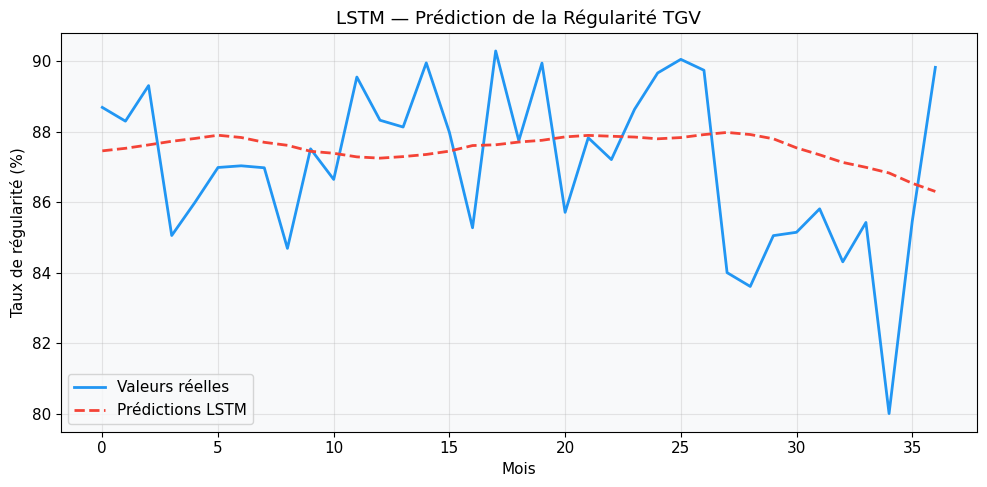

 Graphique LSTM sauvegardé


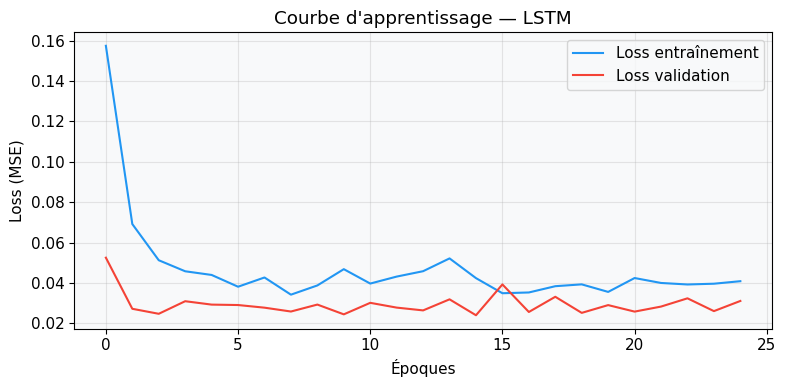

 Courbe de loss sauvegardée

 ÉTAPE 4 TERMINÉE — ML + DEEP LEARNING


In [ ]:
# LSTM (avec le rechargement de df_regularite

# --- Rechargement des données pour le LSTM ---
import pandas as pd, numpy as np
df_regularite = pd.read_csv('regularite_nettoye.csv')
df_regularite['date'] = pd.to_datetime(df_regularite['date'])

# ============================
# ÉTAPE 4B — DEEP LEARNING
# LSTM — SÉRIES TEMPORELLES
# ============================
print("\n" + "="*50)
print("ÉTAPE 4B — DEEP LEARNING LSTM")
print("Prédiction de la régularité TGV (séries temporelles)")
print("="*50)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# Préparation des données temporelles
serie = df_regularite['regularite_composite'].values.reshape(-1, 1)

# Normalisation entre 0 et 1
scaler_lstm = MinMaxScaler()
serie_norm  = scaler_lstm.fit_transform(serie)

# Création des séquences (fenêtre de 12 mois)
def creer_sequences(data, window=12):
    X_seq, y_seq = [], []
    for i in range(len(data) - window):
        X_seq.append(data[i:i+window])
        y_seq.append(data[i+window])
    return np.array(X_seq), np.array(y_seq)

X_lstm, y_lstm = creer_sequences(serie_norm, window=12)
print(f"Séquences créées : {X_lstm.shape[0]} séquences de 12 mois")

# Division Train/Test 70% / 30%
split = int(len(X_lstm) * 0.70)
X_train_l, X_test_l = X_lstm[:split], X_lstm[split:]
y_train_l, y_test_l = y_lstm[:split], y_lstm[split:]

print(f"Entraînement : {len(X_train_l)} séquences ({len(X_train_l)/len(X_lstm)*100:.1f}%)")
print(f"Test         : {len(X_test_l)} séquences ({len(X_test_l)/len(X_lstm)*100:.1f}%)")

# Construction du modèle LSTM
model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(12, 1)),
    Dropout(0.2),
    LSTM(25, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.summary()

# Entraînement avec early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\nEntraînement du modèle LSTM...")
history = model_lstm.fit(
    X_train_l, y_train_l,
    epochs=100,
    batch_size=8,
    validation_data=(X_test_l, y_test_l),
    callbacks=[early_stop],
    verbose=1
)
print(" Modèle LSTM entraîné avec succès")

# Évaluation LSTM
y_pred_lstm = model_lstm.predict(X_test_l)

# Dénormalisation pour obtenir les vraies valeurs
y_pred_reel = scaler_lstm.inverse_transform(y_pred_lstm)
y_test_reel = scaler_lstm.inverse_transform(y_test_l)

# Calcul MAE
mae = np.mean(np.abs(y_pred_reel - y_test_reel))
rmse = np.sqrt(np.mean((y_pred_reel - y_test_reel)**2))

print(f"\n--- MÉTRIQUES LSTM ---")
print(f"MAE  (Erreur absolue moyenne) : {mae:.4f}%")
print(f"RMSE (Racine erreur quadratique) : {rmse:.4f}%")

# Graphique prédictions vs réalité
plt.figure(figsize=(10, 5))
plt.plot(y_test_reel, label='Valeurs réelles', color='#2196F3', linewidth=2)
plt.plot(y_pred_reel, label='Prédictions LSTM', color='#F44336',
         linewidth=2, linestyle='--')
plt.title('LSTM — Prédiction de la Régularité TGV')
plt.xlabel('Mois')
plt.ylabel('Taux de régularité (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_predictions.png', dpi=150)
plt.show()
print(" Graphique LSTM sauvegardé")

# Courbe de loss (apprentissage)
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Loss entraînement', color='#2196F3')
plt.plot(history.history['val_loss'], label='Loss validation', color='#F44336')
plt.title('Courbe d\'apprentissage — LSTM')
plt.xlabel('Époques')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_loss.png', dpi=150)
plt.show()
print(" Courbe de loss sauvegardée")

print("\n ÉTAPE 4 TERMINÉE — ML + DEEP LEARNING")

## Étape 5 — Visualisation des données
Six graphiques d'exploration puis un dashboard de synthèse.

 Données rechargées


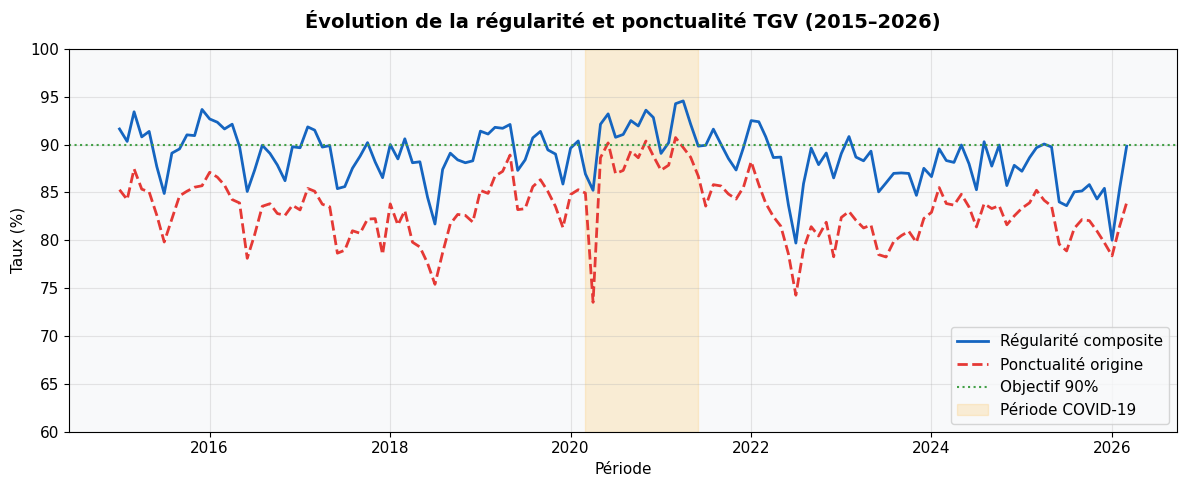

 Graphique 1 sauvegardé


In [ ]:
# Graphique 1 (évolution régularité)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================
# RECHARGEMENT DES DONNÉES
# ============================
df_liaisons       = pd.read_csv('liaisons_nettoye.csv')
df_regularite     = pd.read_csv('regularite_nettoye.csv')
df_frequentation  = pd.read_csv('frequentation_nettoye.csv')

df_regularite['date']  = pd.to_datetime(df_regularite['date'])
df_liaisons['date']    = pd.to_datetime(df_liaisons['date'])

print(" Données rechargées")

# Style global
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#F8F9FA'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3
plt.rcParams['font.size']        = 11

# ============================
# GRAPHIQUE 1 - Evolution régularité TGV
# ============================
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_regularite['date'], df_regularite['regularite_composite'],
        color='#1565C0', linewidth=2, label='Régularité composite')
ax.plot(df_regularite['date'], df_regularite['ponctualite_origine'],
        color='#E53935', linewidth=2, linestyle='--', label='Ponctualité origine')
ax.axhline(y=90, color='#43A047', linewidth=1.5, linestyle=':', label='Objectif 90%')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.15, color='orange', label='Période COVID-19')

ax.set_title("Évolution de la régularité et ponctualité TGV (2015–2026)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Période")
ax.set_ylabel("Taux (%)")
ax.legend(loc='lower right')
ax.set_ylim(60, 100)
plt.tight_layout()
plt.savefig('graphique1_evolution_regularite.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphique 1 sauvegardé")

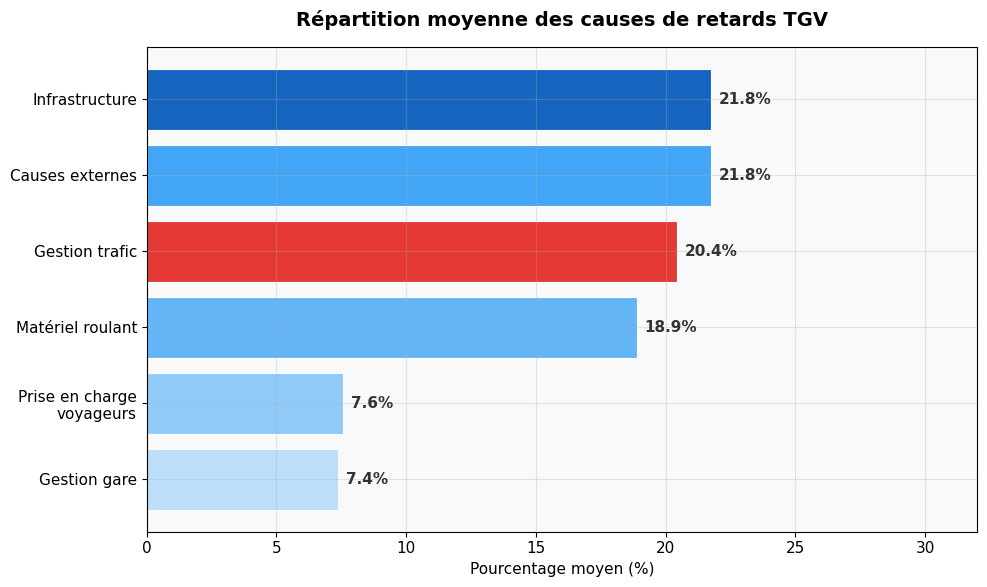

 Graphique 2 sauvegardé


In [ ]:
# Graphique 2 (causes des retards)

# ============================
# GRAPHIQUE 2 - Causes des retards
# ============================
causes = {
    'Causes externes'    : df_liaisons['prct_cause_externe'].mean(),
    'Infrastructure'     : df_liaisons['prct_cause_infra'].mean(),
    'Gestion trafic'     : df_liaisons['prct_cause_gestion_trafic'].mean(),
    'Matériel roulant'   : df_liaisons['prct_cause_materiel_roulant'].mean(),
    'Gestion gare'       : df_liaisons['prct_cause_gestion_gare'].mean(),
    'Prise en charge\nvoyageurs': df_liaisons['prct_cause_prise_en_charge_voyageurs'].mean()
}

causes_df = pd.DataFrame(list(causes.items()), columns=['Cause', 'Pourcentage'])
causes_df = causes_df.sort_values('Pourcentage', ascending=True)

colors = ['#BBDEFB', '#90CAF9', '#64B5F6', '#E53935', '#42A5F5', '#1565C0']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(causes_df['Cause'], causes_df['Pourcentage'],
               color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, causes_df['Pourcentage']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', color='#333')

ax.set_title("Répartition moyenne des causes de retards TGV",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Pourcentage moyen (%)")
ax.set_xlim(0, 32)
plt.tight_layout()
plt.savefig('graphique2_causes_retards.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphique 2 sauvegardé")

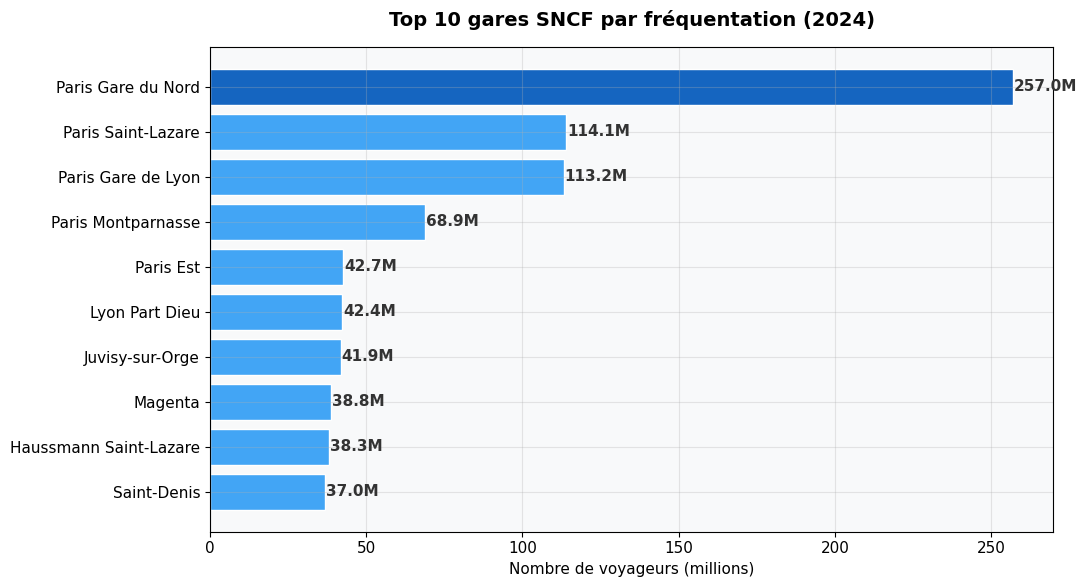

 Graphique 3 sauvegardé


In [ ]:
# ============================
# GRAPHIQUE 3 - Top 10 gares fréquentées
# ============================
top10 = (df_frequentation[['nom_gare', 'total_voyageurs_2024']]
         .dropna()
         .sort_values('total_voyageurs_2024', ascending=False)
         .head(10))

top10['millions'] = top10['total_voyageurs_2024'] / 1_000_000

colors_top = ['#1565C0' if i == 0 else '#42A5F5' for i in range(len(top10))]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10['nom_gare'][::-1], top10['millions'][::-1],
               color=colors_top[::-1], edgecolor='white')

for bar, val in zip(bars, top10['millions'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}M', va='center', fontweight='bold', color='#333')

ax.set_title("Top 10 gares SNCF par fréquentation (2024)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Nombre de voyageurs (millions)")
plt.tight_layout()
plt.savefig('graphique3_top10_gares.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphique 3 sauvegardé")

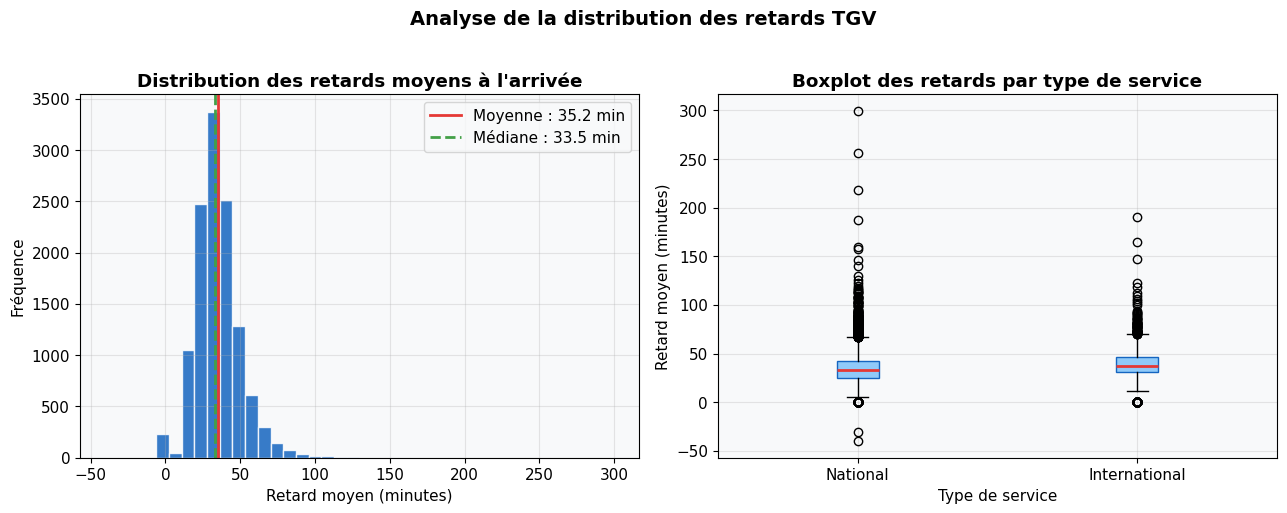

 Graphique 4 sauvegardé


In [ ]:
# Graphique 4 (distribution + boxplot)

# ============================
# GRAPHIQUE 4 - Distribution des retards
# ============================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme
axes[0].hist(df_liaisons['retard_moyen_arrivee'], bins=40, color='#1565C0',
             edgecolor='white', alpha=0.85)
axes[0].axvline(df_liaisons['retard_moyen_arrivee'].mean(), color='#E53935', linewidth=2,
                label=f"Moyenne : {df_liaisons['retard_moyen_arrivee'].mean():.1f} min")
axes[0].axvline(df_liaisons['retard_moyen_arrivee'].median(), color='#43A047', linewidth=2,
                linestyle='--', label=f"Médiane : {df_liaisons['retard_moyen_arrivee'].median():.1f} min")
axes[0].set_title("Distribution des retards moyens à l'arrivée", fontweight='bold')
axes[0].set_xlabel("Retard moyen (minutes)")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

# Boxplot par catégorie service
services = df_liaisons['service'].unique()
data_box  = [df_liaisons[df_liaisons['service'] == s]['retard_moyen_arrivee'].values
             for s in services]

bp = axes[1].boxplot(data_box, labels=services, patch_artist=True,
                     boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
                     medianprops=dict(color='#E53935', linewidth=2))
axes[1].set_title("Boxplot des retards par type de service", fontweight='bold')
axes[1].set_xlabel("Type de service")
axes[1].set_ylabel("Retard moyen (minutes)")

plt.suptitle("Analyse de la distribution des retards TGV",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graphique4_distribution_retards.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphique 4 sauvegardé")

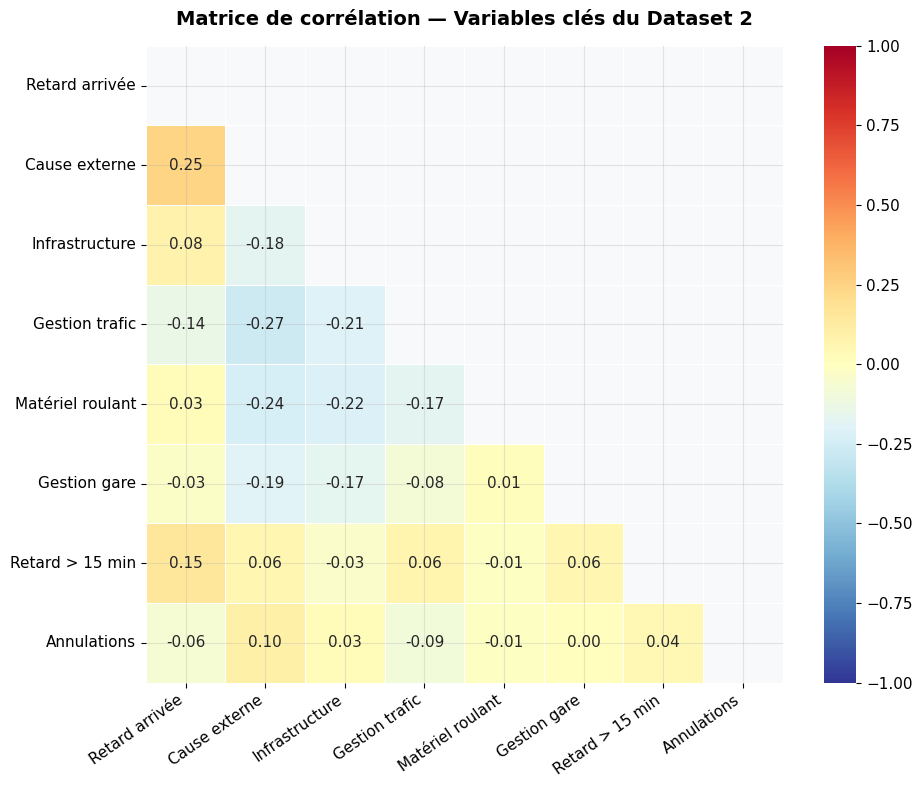

 Graphique 5 sauvegardé


In [ ]:
# ============================
# GRAPHIQUE 5 - Matrice de corrélation
# ============================
cols_corr = ['retard_moyen_arrivee', 'prct_cause_externe', 'prct_cause_infra',
             'prct_cause_gestion_trafic', 'prct_cause_materiel_roulant',
             'prct_cause_gestion_gare', 'nb_train_retard_sup_15', 'nb_annulation']

labels_corr = ['Retard arrivée', 'Cause externe', 'Infrastructure', 'Gestion trafic',
               'Matériel roulant', 'Gestion gare', 'Retard > 15 min', 'Annulations']

corr_matrix = df_liaisons[cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, vmin=-1, vmax=1, xticklabels=labels_corr,
            yticklabels=labels_corr, ax=ax, linewidths=0.5, square=True)
ax.set_title("Matrice de corrélation — Variables clés du Dataset 2",
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('graphique5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphique 5 sauvegardé")

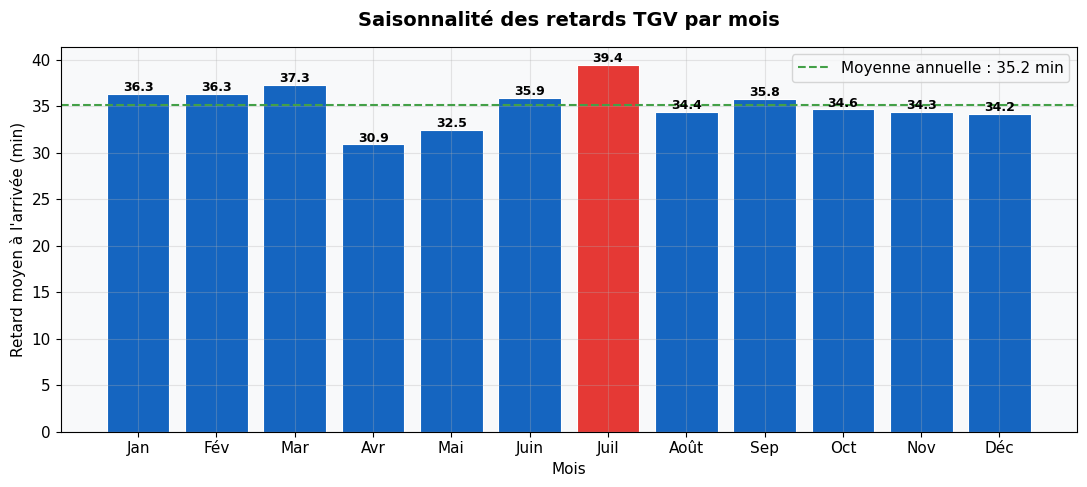

 Graphique 6 sauvegardé


In [ ]:
# Graphique 6 (saisonnalité)

# ============================
# GRAPHIQUE 6 - Saisonnalité des retards
# ============================
df_liaisons['mois'] = pd.to_datetime(df_liaisons['date']).dt.month
df_liaisons['annee'] = pd.to_datetime(df_liaisons['date']).dt.year

retard_mois = (df_liaisons.groupby('mois')['retard_moyen_arrivee']
               .mean().reset_index())

mois_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin',
               'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

colors_mois = ['#E53935' if v == retard_mois['retard_moyen_arrivee'].max()
               else '#1565C0' for v in retard_mois['retard_moyen_arrivee']]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(1, 13), retard_mois['retard_moyen_arrivee'],
              color=colors_mois, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, retard_mois['retard_moyen_arrivee']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(mois_labels)
ax.set_title("Saisonnalité des retards TGV par mois", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Mois")
ax.set_ylabel("Retard moyen à l'arrivée (min)")
ax.axhline(retard_mois['retard_moyen_arrivee'].mean(), color='#43A047', linestyle='--',
           linewidth=1.5, label=f"Moyenne annuelle : {retard_mois['retard_moyen_arrivee'].mean():.1f} min")
ax.legend()
plt.tight_layout()
plt.savefig('graphique6_saisonnalite.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphique 6 sauvegardé")

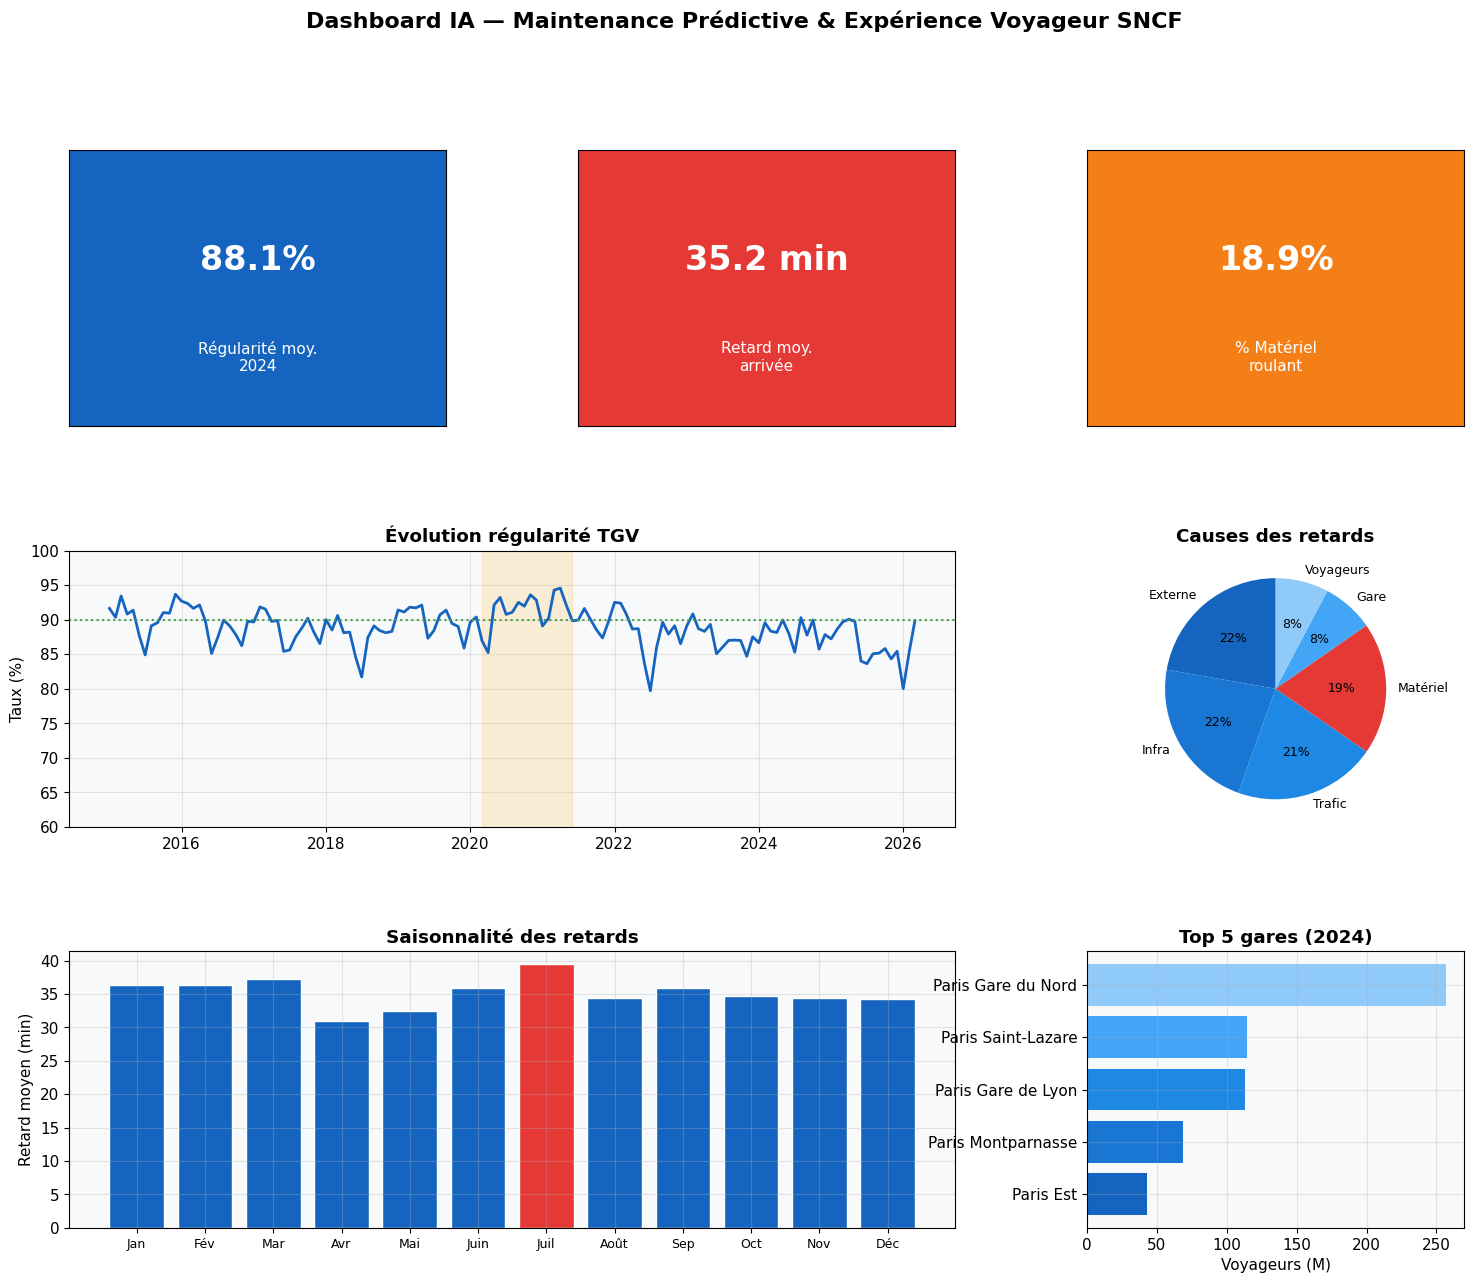

 Dashboard final sauvegardé

 SECTION 5.3 TERMINÉE

Fichiers générés :
  → graphique1_evolution_regularite.png
  → graphique2_causes_retards.png
  → graphique3_top10_gares.png
  → graphique4_distribution_retards.png
  → graphique5_correlation.png
  → graphique6_saisonnalite.png
  → dashboard_final.png


In [ ]:
# ============================
# DASHBOARD FINAL
# ============================
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Dashboard IA — Maintenance Prédictive & Expérience Voyageur SNCF",
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig,
                       hspace=0.45, wspace=0.35)

# --- KPIs en haut ---
kpis = [
    ("Régularité moy.\n2024", f"{df_regularite[df_regularite['date'].dt.year == 2024]['regularite_composite'].mean():.1f}%", '#1565C0'),
    ("Retard moy.\narrivée", f"{df_liaisons['retard_moyen_arrivee'].mean():.1f} min", '#E53935'),
    ("% Matériel\nroulant", f"{df_liaisons['prct_cause_materiel_roulant'].mean():.1f}%", '#F57F17'),
]

for i, (label, valeur, couleur) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[0, i])
    ax_kpi.set_facecolor(couleur)
    ax_kpi.text(0.5, 0.6, valeur, ha='center', va='center',
                fontsize=24, fontweight='bold', color='white',
                transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.25, label, ha='center', va='center',
                fontsize=11, color='white',
                transform=ax_kpi.transAxes)
    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])

# --- Ligne 2 : Évolution régularité ---
ax1 = fig.add_subplot(gs[1, :2])
ax1.plot(df_regularite['date'],
         df_regularite['regularite_composite'],
         color='#1565C0', linewidth=2)
ax1.axhline(90, color='#43A047', linestyle=':', linewidth=1.5)
ax1.axvspan(pd.Timestamp('2020-03-01'),
            pd.Timestamp('2021-06-01'),
            alpha=0.15, color='orange')
ax1.set_title("Évolution régularité TGV", fontweight='bold')
ax1.set_ylabel("Taux (%)")
ax1.set_ylim(60, 100)

# --- Causes retards ---
ax2 = fig.add_subplot(gs[1, 2])
causes_vals = [
    df_liaisons['prct_cause_externe'].mean(),
    df_liaisons['prct_cause_infra'].mean(),
    df_liaisons['prct_cause_gestion_trafic'].mean(),
    df_liaisons['prct_cause_materiel_roulant'].mean(),
    df_liaisons['prct_cause_gestion_gare'].mean(),
    df_liaisons['prct_cause_prise_en_charge_voyageurs'].mean()
]
causes_noms = ['Externe', 'Infra', 'Trafic',
               'Matériel', 'Gare', 'Voyageurs']
colors_pie   = ['#1565C0', '#1976D2', '#1E88E5',
                '#E53935', '#42A5F5', '#90CAF9']

wedges, texts, autotexts = ax2.pie(
    causes_vals,
    labels=causes_noms,
    colors=colors_pie,
    autopct='%1.0f%%',
    startangle=90,
    textprops={'fontsize': 9}
)
ax2.set_title("Causes des retards", fontweight='bold')

# --- Ligne 3 : Saisonnalité ---
ax3 = fig.add_subplot(gs[2, :2])
ax3.bar(range(1, 13),
        retard_mois['retard_moyen_arrivee'],
        color=colors_mois, edgecolor='white')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(mois_labels, fontsize=9)
ax3.set_title("Saisonnalité des retards", fontweight='bold')
ax3.set_ylabel("Retard moyen (min)")

# --- Top 5 gares ---
ax4 = fig.add_subplot(gs[2, 2])
top5 = (df_frequentation[['nom_gare', 'total_voyageurs_2024']]
        .dropna()
        .sort_values('total_voyageurs_2024', ascending=False)
        .head(5))
top5['M'] = top5['total_voyageurs_2024'] / 1_000_000

ax4.barh(top5['nom_gare'][::-1],
         top5['M'][::-1],
         color=['#1565C0', '#1976D2',
                '#1E88E5', '#42A5F5', '#90CAF9'])
ax4.set_title("Top 5 gares (2024)", fontweight='bold')
ax4.set_xlabel("Voyageurs (M)")

plt.savefig('dashboard_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Dashboard final sauvegardé")

print("\n SECTION 5.3 TERMINÉE")
print("\nFichiers générés :")
print("  → graphique1_evolution_regularite.png")
print("  → graphique2_causes_retards.png")
print("  → graphique3_top10_gares.png")
print("  → graphique4_distribution_retards.png")
print("  → graphique5_correlation.png")
print("  → graphique6_saisonnalite.png")
print("  → dashboard_final.png")

In [ ]:
# Annexe : scripts commentés

# ════════════════════════════════════════════════════════════
# ANNEXE — SCRIPTS COMMENTÉS
# ════════════════════════════════════════════════════════════

# ------------------------------------------------------------
# 1) SCRIPT DE TRAITEMENT (nettoyage)
# ------------------------------------------------------------
import pandas as pd
df_reg  = pd.read_csv(url1, sep=';')   # régularité nationale  (135 lignes)
df_liai = pd.read_csv(url2, sep=';')   # régularité par liaison (12 181 lignes)
df_freq = pd.read_csv(url3, sep=';')   # fréquentation gares    (3 021 lignes)

df_liai = df_liai.drop(columns=['commentaire_annulation',
                                'commentaire_retards_depart',
                                'commentaires_retard_arrivee'])
df_reg['date']  = pd.to_datetime(df_reg['date'])
df_liai['date'] = pd.to_datetime(df_liai['date'])

# Fige la periode a mars 2026 (coherent avec le memoire et la cellule principale)
df_reg  = df_reg[df_reg['date']  <= '2026-03-31']
df_liai = df_liai[df_liai['date'] <= '2026-03-31']
for col in ['direction_regionale_gares', 'segmentation_drg', 'segmentation_marketing']:
    df_freq[col] = df_freq[col].fillna('Non renseigné')

# ------------------------------------------------------------
# 2) SCRIPT D'ENTRAÎNEMENT
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- Modèle 1 : Random Forest (variables opérationnelles, SANS fuite) ---
seuil = df_liai['prct_cause_materiel_roulant'].median()
df_liai['risque_materiel'] = (df_liai['prct_cause_materiel_roulant'] >= seuil).astype(int)

X, y = df_liai[features], df_liai['risque_materiel']   # 'features' = liste honnête (Cellule 10)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5,
                            random_state=42, class_weight='balanced')
rf.fit(X_tr, y_tr)

# --- Modèle 2 : LSTM (prévision de série temporelle) ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(12, 1)),
    Dropout(0.2),
    LSTM(25, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model.fit(X_train_l, y_train_l, epochs=100, batch_size=8,
          validation_data=(X_test_l, y_test_l), callbacks=[es])

# ------------------------------------------------------------
# 3) SCRIPT DE TEST / ÉVALUATION
# ------------------------------------------------------------
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# --- Random Forest ---
y_pred, y_proba = rf.predict(X_te), rf.predict_proba(X_te)[:, 1]
print("F1 :", f1_score(y_te, y_pred, average='weighted'))
print("AUC-ROC :", roc_auc_score(y_te, y_proba))
print(classification_report(y_te, y_pred, target_names=['Risque Faible', 'Risque Élevé']))

# --- LSTM ---
y_pred_reel = scaler_lstm.inverse_transform(model.predict(X_test_l))
y_test_reel = scaler_lstm.inverse_transform(y_test_l)
mae  = np.mean(np.abs(y_pred_reel - y_test_reel))
rmse = np.sqrt(np.mean((y_pred_reel - y_test_reel) ** 2))
print(f"MAE : {mae:.2f}%  |  RMSE : {rmse:.2f}%")

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.2436 - val_loss: 0.0238
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0476 - val_loss: 0.0351
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0393 - val_loss: 0.0235
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0447 - val_loss: 0.0301
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0397 - val_loss: 0.0294
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0381 - val_loss: 0.0272
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0387 - val_loss: 0.0266
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0377 - val_loss: 0.0354
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0429 - val_loss: 0.0235
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0403 - val_loss: 0.0321
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0371 - val_loss: 0.0284
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

## Conclusion

- **Random Forest (sans fuite)** : AUC ≈ 0,70 — établit une baseline honnête sur données open data agrégées.
- **LSTM** : MAE ≈ 1,90 % — prédiction de la régularité TGV sous l'objectif de 3 %.

L'écart entre la performance du Random Forest et sa cible de production (AUC > 0,90) démontre le point central
du projet : la maintenance réellement prédictive exige des données granulaires internes (vibrations, âge et
kilométrage des rames, historique des réparations), que l'open data agrégée ne peut remplacer.